# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [ ]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = ["SGD"]
problem_abbr_names = ["VANRYZIN-2"]
# problem_abbr_names = ["PARAMESTI-1"]

num_macroreps = 1
num_postreps = num_macroreps * 20
num_postreps_init_opt = num_postreps  

In [3]:
# Function that instantiates a problem instance given its name and scales the dimension of the problem for a given dimension argument
from simopt.experiment_base import instantiate_problem, instantiate_solver, Problem, ProblemsSolvers, ProblemSolver
from simopt.base import Solution
import numpy as np
import random
import hashlib
from mrg32k3a.mrg32k3a import MRG32k3a

SCALABLE_PROBLEMS = ["VANRYZIN-1", "FIXEDSAN-1", "NETWORK-1", "ROSENBROCK-1", "SAN-1", "DYNAMNEWS-1", "FACSIZE-2", "FACSIZE-1", "CONTAM-2"]

def scale_dimension(problem_name: str, budget: int, dimension: int | None = None) -> Problem:
	"""
	Instantiate a problem with a scaled dimension.
	
	All model and problem factors that depend on the dimension are updated
	before instantiation to ensure consistency.
	
	Args:
		problem_name: The abbreviated name of the problem (e.g., "FACSIZE-2")
		dimension: The desired dimension for the problem
		
	Returns:
		A Problem instance configured for the specified dimension
	"""
	if problem_name not in SCALABLE_PROBLEMS or dimension is None:
		# For non-scalable problems, just instantiate with defaults
		# check initial objective funciton value of initial solution 
		problem = instantiate_problem(problem_name, {'budget': budget})
		try :
			init_sol = Solution(problem.factors["initial_solution"], problem)
			#attach RNGs 
			init_sol.attach_rngs([MRG32k3a() for _ in range(problem.model.n_rngs)])
			problem.simulate(init_sol,3)  # This will compute the objective value and ensure the initial solution is valid
			print(f"Initial solution objective value: {init_sol.objectives_mean}")
		except RuntimeError as e :
			print(e)
		return problem
	
	# Build the factors for the new dimension
	model_factors = get_scaled_model_factors(problem_name, dimension)
	problem_factors = get_scaled_problem_factors(problem_name, dimension)
	problem_factors['budget'] = budget
	
	# Instantiate the problem with the scaled factors
	problem = instantiate_problem(
		problem_name,
		problem_fixed_factors=problem_factors,
		model_fixed_factors=model_factors
	)
	
	# Set the problem dimension explicitly
	problem.dim = dimension
	
	# Post-initialization updates for factors that can't be validated during construction
	post_init_updates(problem, problem_name, dimension)
	
	return problem


def get_scaled_model_factors(problem_name: str, dimension: int) -> dict:
	"""
	Generate model factors scaled to the specified dimension.
	
	Args:
		problem_name: The abbreviated name of the problem
		dimension: The target dimension
		
	Returns:
		Dictionary of model factors appropriate for the dimension
	"""
	# Deterministic RNGs based on problem name + dimension
	seed = int(hashlib.sha256(f"{problem_name}:{dimension}".encode()).hexdigest(), 16) % (2**32)
	rng_py = random.Random(seed)
	rng_np = np.random.default_rng(seed)

	if problem_name == 'DYNAMNEWS-1':
		return {
			'num_prod': dimension,
			'c_utility': [float(6 + j) for j in range(dimension)],
			'init_level': [3] * dimension,
			'price': [9.0] * dimension,
			'cost': [5.0] * dimension,
		}
	
	#dimension is increasing the number of ODF classes -- currently set to 6 
	elif problem_name in ('VANRYZIN-1'):
		# Scale VANRYZIN by number of ODF classes (products). "dimension" here
		# refers to the number of ODF classes. Choose a number of flight legs
		# that divides the number of classes so that n_virtual_classes =
		# dimension // n_legs is an integer. Use deterministic RNG for repeatability.
		possible_flights = [i for i in range(2, dimension + 1) if dimension % i == 0]
		if len(possible_flights) == 0:
			no_of_flights = 1
		else:
			no_of_flights = rng_py.choice(possible_flights)
		n_virtual = max(1, dimension // no_of_flights)

		# Build ODF matrix (n_classes x n_legs) ensuring every product uses at least one leg
		odf = []
		for _ in range(dimension):
			row = [rng_py.randint(0, 1) for _ in range(no_of_flights)]
			if sum(row) == 0:
				row[rng_py.randint(0, no_of_flights - 1)] = 1
			odf.append(row)

		capacity = [float(rng_py.randint(100, 600)) for _ in range(no_of_flights)]
		fares = [float(rng_py.uniform(50, 500)) for _ in range(dimension)]

		# Virtual class indexing: shape (n_classes, n_legs). 0 if product doesn't use leg,
		# otherwise an integer in [1, n_virtual]
		vc_index = []
		for j in range(dimension):
			row = []
			for l in range(no_of_flights):
				if odf[j][l] == 1:
					row.append(rng_py.randint(1, n_virtual))
				else:
					row.append(0)
			vc_index.append(row)

		# Protection levels: shape (n_legs, n_virtual). must be non-decreasing and <= capacity
		prot = []
		for l_idx in range(no_of_flights):
			cap = capacity[l_idx]
			vals = sorted(rng_py.uniform(0.0, cap) for _ in range(n_virtual))
			prot.append([float(v) for v in vals])

		return {
			'ODF_leg_matrix': odf,
			'n_virtual_classes': n_virtual,
			'capacity': capacity,
			'n_classes': dimension,
			'fares': fares,
			'virtual_class_indexing': vc_index,
			'protection_levels': prot,
			'gamma_shape': tuple([2.0] * dimension),
			'gamma_scale': tuple([50.0] * dimension),
			'beta_alpha': tuple([2.0] * dimension),
			'beta_beta': tuple([1.0] * dimension),
		}
	
	elif problem_name in ('FACSIZE-1', 'FACSIZE-2'):
		# Use diagonal covariance to avoid expensive Cholesky and reduce rejection rate
		# With mean=500 and std=50 (variance=2500), P(X<0) ≈ 0 for each dimension
		# This makes rejection sampling nearly instant
		variance = 2500.0  # std = 50, mean = 500, so P(X<0) is negligible
		cov_matrix = np.eye(dimension) * variance
		return {
			'mean_vec': [500.0] * dimension,
			'cov': cov_matrix.tolist(),
			'capacity': [float(rng_py.randint(100, 900)) for _ in range(dimension)],
			'n_fac': dimension,
		}
	
	elif problem_name == 'SAN-1':
		# Calculate appropriate num_nodes for the number of edges (dimension)
		# For a DAG: we need num_nodes such that we can have 'dimension' edges
		# with a path from node 1 to num_nodes
		num_nodes = compute_num_nodes_for_dag(dimension)
		arcs = build_san_dag(num_nodes, dimension, rng=rng_py)
		return {
			'num_arcs': dimension,
			'num_nodes': num_nodes,
			'arcs': arcs,
			'arc_means': tuple(round(rng_py.uniform(1, 10), 2) for _ in range(dimension)),
		}
	
	elif problem_name == 'FIXEDSAN-1':
		num_nodes = max(2, rng_py.randint(2, max(2, dimension)))
		return {
			'num_arcs': dimension,
			'num_nodes': num_nodes,
			'arc_means': tuple(float(rng_py.randint(1, 10)) for _ in range(dimension)),
		}
	
	elif problem_name == 'ROSENBROCK-1':
		return {
			'x': (2.0,) * dimension,
			'variance': 0.4,
		}
	elif problem_name == 'ZAKHAROV-1':
		return {
			'x': (2.0,) * dimension,
			'variance': 0.1,
		}   
	
	elif problem_name == 'NETWORK-1':
		process_prob_elem = 1.0 / dimension
		mode_transit_time = [round(rng_py.uniform(0.01, 5), 3) for _ in range(dimension)]
		return {
			'process_prob': [process_prob_elem] * dimension,
			'cost_process': [0.1 / (x + 1) for x in range(dimension)],
			'cost_time': [round(rng_py.uniform(0.01, 1), 3) for _ in range(dimension)],
			'mode_transit_time': mode_transit_time,
			'lower_limits_transit_time': [x / 2 for x in mode_transit_time],
			'upper_limits_transit_time': [2 * x for x in mode_transit_time],
			'n_networks': dimension,
		}
	
	elif problem_name == 'CONTAM-2':
		return {
			'stages': dimension,
			'prev_decision': (0.0,) * dimension,
		}
	
	return {}


def get_scaled_problem_factors(problem_name: str, dimension: int) -> dict:
	"""
	Generate problem factors scaled to the specified dimension.
	
	Only includes factors that will pass validation during construction.
	Factors that depend on model state are updated post-initialization.
	
	Args:
		problem_name: The abbreviated name of the problem
		dimension: The target dimension
		
	Returns:
		Dictionary of problem factors appropriate for the dimension
	"""
	if problem_name == 'DYNAMNEWS-1':
		return {
			'initial_solution': (3.0,) * dimension,
		}
	
	elif problem_name in ('FACSIZE-1', 'FACSIZE-2'):
		# NOTE: installation_costs is validated against NUM_FACILITIES constant (=3)
		# So we can't pass it here - it will be updated post-initialization
		return {
			'initial_solution': (100.0,) * dimension,
			'installation_budget': 500.0 * (dimension / 3),  # Scale budget with dimension
		}
	
	elif problem_name in ('SAN-1', 'FIXEDSAN-1'):
		# NOTE: arc_costs is validated against NUM_ARCS constant (=13)
		# So we can't pass it here - it will be updated post-initialization
		return {
			'initial_solution': (1.0,) * dimension,
		}
	
	elif problem_name in ('VANRYZIN-1'):
		# Construct a sensible initial_solution (flattened protection levels)
		# using the same deterministic RNG logic as the model factors so
		# that the initial solution is consistent with the generated model.
		seed = int(hashlib.sha256(f"{problem_name}:{dimension}".encode()).hexdigest(), 16) % (2**32)
		rng_py = random.Random(seed)
		possible_flights = [i for i in range(1, dimension + 1) if dimension % i == 0]
		if len(possible_flights) == 0:
			no_of_flights = 1
		else:
			no_of_flights = rng_py.choice([i for i in possible_flights if i >= 1])
		n_virtual = max(1, dimension // no_of_flights)

		# Build protection levels per leg and flatten in leg-major order
		prot = []
		for _l in range(no_of_flights):
			cap = float(rng_py.randint(100, 600))
			vals = sorted(rng_py.uniform(0.0, cap) for _ in range(n_virtual))
			prot.append([float(v) for v in vals])

		# Flatten leg-major: (y_{0,1},...,y_{0,K}, y_{1,1},...,y_{L-1,K})
		flat = tuple(prot[l][k] for l in range(len(prot)) for k in range(len(prot[l])))
		return {
			'initial_solution': flat,
		}
	
	elif problem_name == 'ROSENBROCK-1':
		return {
			'initial_solution': (2.0,) * dimension,
		}
	
	elif problem_name == 'ZAKHAROV-1':
		return {
			'initial_solution': (2.0,) * dimension,
		}
	
	elif problem_name == 'NETWORK-1':
		return {
			'initial_solution': (1.0 / dimension,) * dimension,
		}
	
	elif problem_name == 'CONTAM-2':
		return {
			'initial_solution': (0.0,) * dimension,
		}
	
	return {}


def post_init_updates(problem: Problem, problem_name: str, dimension: int) -> None:
	"""
	Update problem factors after initialization for factors that couldn't be set during construction.
	
	Some factors are validated against hardcoded constants during construction,
	so they need to be updated after the problem is instantiated.
	
	Args:
		problem: The problem instance to update
		problem_name: The abbreviated name of the problem
		dimension: The target dimension
	"""
	if problem_name in ('FACSIZE-1', 'FACSIZE-2'):
		# Update installation_costs after construction to match the new dimension
		problem.factors['installation_costs'] = (1.0,) * dimension
	
	elif problem_name in ('SAN-1', 'FIXEDSAN-1'):
		# Update arc_costs after construction to match the new dimension
		# arc_costs is used in replicate(): np.sum(arc_costs / x)
		problem.factors['arc_costs'] = (1.0,) * dimension

	elif problem_name in ('VANRYZIN-1', 'VANRYZIN-2'):
		# Ensure initial_solution length matches n_legs * n_virtual_classes
		capacity = problem.model.factors['capacity']
		n_virtual = int(problem.model.factors['n_virtual_classes'])
		n_virtual = max(1, n_virtual)
		prot = []
		for c in capacity:
			row = [float((k + 1) * c / (n_virtual + 1)) for k in range(n_virtual)]
			prot.append(row)
		flat = tuple(v for row in prot for v in row)
		problem.factors['initial_solution'] = flat

def compute_num_nodes_for_dag(num_edges: int) -> int:
	"""
	Compute an appropriate number of nodes for a DAG with the given number of edges.
	
	For a DAG with n nodes where we need a path from 1 to n:
	- Minimum edges needed: n-1 (a simple path)
	- Maximum edges possible: n*(n-1)/2 (complete DAG)
	
	We want to find the smallest n such that n*(n-1)/2 >= num_edges
	and n-1 <= num_edges (so we have enough edges for connectivity).
	
	Args:
		num_edges: Desired number of edges
		
	Returns:
		Number of nodes to use
	"""
	# We need at least num_edges + 1 nodes in the worst case (simple path),
	# but we want fewer nodes with more edges between them.
	# Solve: n*(n-1)/2 >= num_edges => n^2 - n - 2*num_edges >= 0
	# n >= (1 + sqrt(1 + 8*num_edges)) / 2
	
	import math
	min_nodes = int(math.ceil((1 + math.sqrt(1 + 8 * num_edges)) / 2))
	
	# Ensure we have at least 2 nodes and the path is possible
	min_nodes = max(2, min_nodes)
	
	# Also ensure num_edges >= min_nodes - 1 (need at least a spanning path)
	# If not, we need more nodes
	while min_nodes - 1 > num_edges:
		min_nodes -= 1
	
	return min_nodes


def build_san_dag(num_nodes: int, num_edges: int, rng: random.Random | None = None) -> list[tuple[int, int]]:
	"""
	Build a directed acyclic graph (DAG) suitable for the SAN model.
	
	The SAN model requires:
	1. Directed edges (arcs) from lower-numbered to higher-numbered nodes
	2. A path must exist from node 1 to node num_nodes
	3. Every node must be reachable from node 1 (for backtracking to work)
	
	This function first creates a simple sequential path from 1 to num_nodes
	(1→2→3→...→n), then adds additional random forward edges until reaching num_edges.
	
	Args:
		num_nodes: Number of nodes (numbered 1 to num_nodes)
		num_edges: Desired number of directed edges
		
	Returns:
		List of (source, target) tuples representing directed edges
		
	Raises:
		ValueError: If the requested configuration is impossible
	"""
	min_edges = num_nodes - 1  # Simple path from 1 to num_nodes
	max_edges = num_nodes * (num_nodes - 1) // 2  # Complete DAG
	
	if num_edges < min_edges:
		raise ValueError(
			f"Cannot create DAG with path 1→{num_nodes}: need at least {min_edges} edges, "
			f"but only {num_edges} requested"
		)
	
	if num_edges > max_edges:
		raise ValueError(
			f"Cannot create DAG with {num_edges} edges: maximum possible is {max_edges} "
			f"for {num_nodes} nodes"
		)
	
	edges = set()
	
	# Step 1: Create a guaranteed SEQUENTIAL path from node 1 to node num_nodes
	# This ensures every node has a predecessor reachable from node 1
	# Path: 1 → 2 → 3 → ... → num_nodes
	for i in range(1, num_nodes):
		edges.add((i, i + 1))
	
	# Step 2: Add additional random forward edges until we reach num_edges
	if len(edges) < num_edges:
		if rng is None:
			rng: random.Random = random.Random()
		# Generate all possible forward edges not yet in the graph
		all_possible_edges = []
		for i in range(1, num_nodes):
			for j in range(i + 1, num_nodes + 1):
				edge = (i, j)
				if edge not in edges:
					all_possible_edges.append(edge)
		
		# Shuffle and add as many as needed
		rng.shuffle(all_possible_edges)
		edges_needed = num_edges - len(edges)
		
		for edge in all_possible_edges[:edges_needed]:
			edges.add(edge)
	
	return list(edges)


def validate_solver_and_problem_names(solver_name: str, problem_name: str) -> None:
	"""Pre-flight validation for clearer errors before heavy work."""
	try:
		_ = instantiate_solver(solver_name=solver_name, fixed_factors={}, solver_rename=solver_name)
	except Exception as e:
		raise ValueError(f"Unknown or invalid solver code '{solver_name}'. Original error: {e}") from e

	try:
		_ = instantiate_problem(problem_name, problem_fixed_factors=None, model_fixed_factors=None)
	except Exception as e:
		raise ValueError(f"Unknown problem code '{problem_name}'. Original error: {e}") from e


def build_connected_graph(num_nodes: int, num_edges: int, rng: random.Random | None = None) -> list[tuple[int, int]]:
	"""
	Build a connected graph with the specified number of nodes and edges.
	
	Starts with a spanning tree to ensure connectivity, then adds random edges
	until the desired number is reached.
	"""
	if num_edges < num_nodes - 1:
		raise ValueError(f"Cannot create connected graph: need at least {num_nodes - 1} edges for {num_nodes} nodes")
	
	edges = set()
	
	if rng is None:
		rng: random.Random = random.Random()

	# Create a spanning tree first to ensure connectivity
	nodes = list(range(num_nodes))
	rng.shuffle(nodes)
	for i in range(1, num_nodes):
		a = nodes[i]
		b = nodes[rng.randint(0, i - 1)]
		edges.add((min(a, b), max(a, b)))
	
	# Add random edges until we reach the desired number
	max_possible_edges = num_nodes * (num_nodes - 1) // 2
	target_edges = min(num_edges, max_possible_edges)
	
	attempts = 0
	max_attempts = target_edges * 10  # Prevent infinite loop
	while len(edges) < target_edges and attempts < max_attempts:
		a = rng.randint(0, num_nodes - 1)
		b = rng.randint(0, num_nodes - 1)
		if a != b:
			edges.add((min(a, b), max(a, b)))
		attempts += 1
	
	return list(edges)

In [4]:
#Dictionary for different subspace sizes for each problem (only used for ASTROMORF)
solver_renames = {
	'ASTROMORF': 'ASTROMoRF',
	'OMoRF': 'OMoRF',
	'ADAM': 'ADAM',
	'ASTRODF': 'ASTRO-DF',
	'NELDMD': 'NELDER MEAD',
	'RNDSRCH': 'RANDOM SEARCH',
	'STRONG': 'STRONG',
  'OMORF': 'OMoRF'
}

fixed_factors = {
    "ADP_SOLVER": {
        "VANRYZIN-2": {"wrapped_solver": "ASTROMORF", "wrapped_solver_factors": {"initial subspace dimension": 2, "polynomial degree": 4, "adaptive subspace dimension": True}} #r=5
    },
    "ADAM": {
      "DYNAMNEWS-1":  {"crn_across_solns": False, "r": 5,  "beta_1": 0.931,  "beta_2": 0.9624, "alpha": 0.38}, #r=5
      "NETWORK-1":    {"crn_across_solns": False, "r": 47, "beta_1": 0.824,  "beta_2": 0.925,  "alpha": 0.13}, #r=47
      "PARAMESTI-1":  {"crn_across_solns": False, "r": 5,  "beta_1": 0.931,  "beta_2": 0.9624, "alpha": 0.38}, #r=5
      "ROSENBROCK-1": {"crn_across_solns": False, "r": 90, "beta_1": 0.848,  "beta_2": 0.9874, "alpha": 1.13}, #r=90
      "SAN-1":        {"crn_across_solns": False, "r": 88, "beta_1": 0.907,  "beta_2": 0.9937, "alpha": 1.5} #r=88
    },
    "ASTRODF": {
      "DYNAMNEWS-1":  {"crn_across_solns": False, "eta_1": 0.1, "eta_2": 0.8, "gamma_1": 3.5, "gamma_2": 0.4, "lambda_min": 5, "ps_sufficient_reduction": 0.94},
      "NETWORK-1":    {"crn_across_solns": False, "eta_1": 0.1, "eta_2": 0.8, "gamma_1": 3.5, "gamma_2": 0.4, "lambda_min": 5, "ps_sufficient_reduction": 0.94},
      "PARAMESTI-1":  {"crn_across_solns": False, "eta_1": 0.1, "eta_2": 0.8, "gamma_1": 2.0, "gamma_2": 0.5,  "lambda_min": 5, "ps_sufficient_reduction": 0.1},
      "ROSENBROCK-1": {"crn_across_solns": False, "eta_1": 0.1, "eta_2": 0.8, "gamma_1": 1.5, "gamma_2": 0.65, "lambda_min": 5,  "ps_sufficient_reduction": 0.56},
      "SAN-1":        {"crn_across_solns": False, "eta_1": 0.1, "eta_2": 0.8, "gamma_1": 3.7, "gamma_2": 0.55, "lambda_min": 5,  "ps_sufficient_reduction": 0.31},
      'VANRYZIN-2':   {"crn_across_solns": False}
    },
    "ASTROMORF": {
      "DYNAMNEWS-1":  {"crn_across_solns": False, "initial subspace dimension": 20, "polynomial degree": 4,  "eta_1": 0.218, "eta_2": 0.29, "gamma_1": 3.4, "gamma_2": 1.97, "gamma_3": 0.38, "lambda_min": 5,  "subproblem_regularisation": 0.06, "ps_sufficient_reduction": 0.16},
      "NETWORK-1":    {"crn_across_solns": False, "initial subspace dimension": 10, "polynomial degree": 2, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 3.0, "gamma_2": 1.2,  "gamma_3": 0.5, "lambda_min": 7, "subproblem_regularisation": 0.28, "ps_sufficient_reduction": 0.1},
      "PARAMESTI-1":  {"crn_across_solns": False, "initial subspace dimension": 1, "polynomial degree": 4, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 2.5, "gamma_2": 2.0, "gamma_3": 0.5,  "lambda_min": 5,  "subproblem_regularisation": 0.33, "ps_sufficient_reduction": 0.1},
      "ROSENBROCK-1": {"crn_across_solns": False, "initial subspace dimension": 20, "polynomial degree": 4, "eta_1": 0.155, "eta_2": 0.52, "gamma_1": 2.8, "gamma_2": 1.52, "gamma_3": 0.5,  "lambda_min": 16, "subproblem_regularisation": 0.25, "ps_sufficient_reduction": 0.5},
      "SAN-1":        {"crn_across_solns": False, "initial subspace dimension": 15, "polynomial degree": 2, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 2.5, "gamma_2": 1.2, "gamma_3": 0.5,"lambda_min": 7,"subproblem_regularisation": 0.25,"ps_sufficient_reduction": 0.1},
      'VANRYZIN-2':   {"crn_across_solns": False, "initial subspace dimension": 2},
    },
    "NELDMD": {
      "DYNAMNEWS-1":  {"crn_across_solns": False, "r": 5,  "alpha": 1.53, "gammap": 2.4, "betap": 0.25, "delta": 0.85, "initial_spread": 0.13},
      "NETWORK-1":    {"crn_across_solns": False, "r": 5, "alpha": 0.59, "gammap": 2.3, "betap": 0.8,  "delta": 0.65, "initial_spread": 0.5},
      "PARAMESTI-1":  {"crn_across_solns": False, "r": 5, "alpha": 0.88, "gammap": 2.8, "betap": 0.55, "delta": 0.1,  "initial_spread": 0.16},
      "ROSENBROCK-1": {"crn_across_solns": False, "r": 5, "alpha": 1.44, "gammap": 2.0, "betap": 0.9,  "delta": 0.55, "initial_spread": 0.07},
      "SAN-1":        {"crn_across_solns": False, "r": 5,  "alpha": 1.53, "gammap": 2.4, "betap": 0.25, "delta": 0.85, "initial_spread" : 0.13}
    },
    "RNDSRCH": {
      "DYNAMNEWS-1":  {"crn_across_solns": False, "sample_size": 94},
      "NETWORK-1":    {"crn_across_solns": False, "sample_size": 75},
      "PARAMESTI-1":  {"crn_across_solns": False, "sample_size": 69},
      "ROSENBROCK-1": {"crn_across_solns": False, "sample_size": 75},
      "SAN-1":        {"crn_across_solns": False, "sample_size": 20}
    },
    "STRONG": {
      "DYNAMNEWS-1":  {"crn_across_solns": False, "n0": 36, "n_r": 5,  "eta_0": 0.02,  "eta_1": 0.35, "gamma_1": 0.87, "gamma_2": 1.07, "lambda_2": 1.438},
      "NETWORK-1":    {"crn_across_solns": False, "n0": 47, "n_r": 39, "eta_0": 0.013, "eta_1": 0.28, "gamma_1": 0.99, "gamma_2": 1.69, "lambda_2": 1.376},
      "PARAMESTI-1":  {"crn_across_solns": False, "n0": 44, "n_r": 30, "eta_0": 0.2, "eta_1": 0.8,  "gamma_1": 0.5, "gamma_2": 2.0,  "lambda_2": 1.001},
      "ROSENBROCK-1": {"crn_across_solns": False, "n0": 22, "n_r": 42, "eta_0": 0.001, "eta_1": 0.38, "gamma_1": 0.56, "gamma_2": 1.57, "lambda_2": 1.063},
      "SAN-1":        {"crn_across_solns": False, "n0": 22, "n_r": 42, "eta_0": 0.001, "eta_1": 0.38, "gamma_1": 0.56, "gamma_2": 1.57, "lambda_2": 1.063}
    },
    "OMORF": {
        "DYNAMNEWS-1" : {"crn_across_solns": False,"initial subspace dimension": 20, "polynomial degree": 4, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 0.5, "gamma_2": 1.2, "gamma_3": 2.5},
        "NETWORK-1" : {"crn_across_solns": False, "initial subspace dimension": 10, "polynomial degree": 2, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 0.5, "gamma_2": 1.2, "gamma_3": 2.5},
        "PARAMESTI-1" : {"crn_across_solns": False, "initial subspace dimension": 1, "polynomial degree": 4, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 0.5, "gamma_2": 1.2, "gamma_3": 2.5},
        "ROSENBROCK-1" : {"crn_across_solns": False, "initial subspace dimension": 1, "polynomial degree": 2, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 0.5, "gamma_2": 1.2, "gamma_3": 2.5},
        "SAN-1" : {"crn_across_solns": False, "initial subspace dimension": 15, "polynomial degree": 2, "eta_1": 0.2, "eta_2": 0.8, "gamma_1": 0.5, "gamma_2": 1.2, "gamma_3": 2.5}
    },
    "SGD": {
        'VANRYZIN-2':   {"crn_across_solns": False}
    }
  }

problems = [] 
for problem_name in problem_abbr_names:
    problem = scale_dimension(problem_name, 50000, 50)
    print(f"Constructed problem {problem.name} with dimension {problem.dim}")
    problems.append(problem)

#Construct a list of lists of ProblemSolver instances to be the experiments argument in the ProblemsSolvers constructor
experiments = []
for solver_name in solver_abbr_names:
    ps_same_solver = []
    for problem in problems:
        solver_rename = solver_renames.get(solver_name, solver_name)
        solver_factors = fixed_factors.get(solver_name, {}).get(problem.name, {})
        solver = instantiate_solver(
            solver_name=solver_name,
            fixed_factors=solver_factors,
            solver_rename=solver_rename
        )

        print(f"Constructed solver {solver.name} for problem {problem.name} with factors: {solver_factors}")

        ps_same_solver.append(ProblemSolver(
            solver = solver, 
            problem = problem
        ))
        # ps_same_solver.append(ProblemSolver(
        #     solver_name=solver_name,
        #     problem_name=problem_name,
        #     solver_fixed_factors=solver_factors,
        #     problem_fixed_factors={'budget': 10000}
        # )) 
    experiments.append(ps_same_solver)



Solver lookahead is enabled, but lookahead_solver is None. Assign problem.lookahead_solver before simulating or disable solver lookahead for this problem/sub-problem.
Constructed problem VANRYZIN-2 with dimension 80
Constructed solver ADP_SOLVER for problem VANRYZIN-2 with factors: {'wrapped_solver': 'ASTROMORF', 'wrapped_solver_factors': {'initial subspace dimension': 2, 'polynomial degree': 4, 'adaptive subspace dimension': True}}
Constructed solver DAVN for problem VANRYZIN-2 with factors: {}
Constructed solver VANRYZIN_SGD for problem VANRYZIN-2 with factors: {}


In [5]:
# Initialize an instance of the experiment class.
from simopt.experiment_base import ProblemsSolvers


mymetaexperiment = ProblemsSolvers(
    experiments=experiments
)

# Write to log file.
mymetaexperiment.log_group_experiment_results()

In [6]:
# Enable logging and show per-experiment complexity estimates
import logging

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

Logging set to INFO. You will see per-pair progress as they start/finish.


In [7]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

2026-04-15 20:05:01,997 | INFO | Running solver ADP_SOLVER on problem VANRYZIN-2.


Budget before backward pass: 50000
[Backwards fit] total backward budget=80000, initial sweep=48000, bellman=32000
  Stage budgets: {1: 32000, 2: 16000}  (cost/state=20)

[GP Backwards Fit] Stage 2  |  budget remaining: 1000000000/80000  |  stage envelope: 16000
  Planning 200 training states (MC cost/state=20)
  GP-V trained on 200 pts.  V range: [11762.9, 79091.4]  (stage budget used: 0/16000)

[GP Backwards Fit] Stage 1  |  budget remaining: 1000000000/80000  |  stage envelope: 32000
  Planning 200 training states (MC cost/state=20)
  GP-V trained on 200 pts.  V range: [15806.3, 141435.5]  (stage budget used: 0/32000)

[Bellman Iter 1/9]  backward remaining: 1000000000, iter cap: 111111111
  Stage 2: V range [11762.9, 79091.4]
  Stage 1: V range [14646.8, 143326.4]
  [Bellman] Max relative V change across stages: 1.6952

[Bellman Iter 2/9]  backward remaining: 1000000000, iter cap: 111111111
  Stage 2: V range [11762.9, 79091.4]
  Stage 1: V range [13802.2, 142437.4]
  [Bellman] Max

2026-04-15 20:22:33,921 | INFO | Finished running 1 mreps in 1051.924 seconds.
2026-04-15 20:22:33,934 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/ADP_SOLVER_on_VANRYZIN-2.pickle
2026-04-15 20:22:33,935 | INFO | Running solver DAVN on problem VANRYZIN-2.


Final solution -- surrogate revenue: 190399.03
  protection levels: (66.79239822449435, 39.696844419539254, 48.93742541562518, 56.31109056394967, 69.58941885159524, 86.80666214549139, 100.92431011604668, 179.99, 179.99, 179.99, 6.84384810194818, 38.389908908970554, 48.72364339211212, 56.31109056394967, 69.58941885159524, 86.80666214549139, 100.92431011604668, 179.99, 179.99, 179.99, 7.970375856268895, 20.58177782449542, 34.21348124357124, 68.10696140345843, 82.71753845615737, 116.94411543275973, 179.99, 179.99, 179.99, 179.99, 7.970375856268895, 20.58177782449542, 34.21348124357124, 68.10696140345843, 82.71753845615737, 116.94411543275973, 179.99, 179.99, 179.99, 179.99, 3.42192405097409, 12.615538764505835, 20.58177782449542, 44.17030302172774, 74.04126049905386, 92.40564634494133, 109.50156963117088, 179.99, 179.99, 179.99, 3.42192405097409, 12.615538764505835, 20.58177782449542, 44.17030302172774, 74.04126049905386, 92.40564634494133, 109.50156963117088, 179.99, 179.99, 179.99, 28.1

2026-04-15 20:22:34,121 | INFO | Finished running 1 mreps in 0.186 seconds.
2026-04-15 20:22:34,127 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/DAVN_on_VANRYZIN-2.pickle
2026-04-15 20:22:34,129 | INFO | Running solver VANRYZIN_SGD on problem VANRYZIN-2.


DAVN simulated revenue from final protection levels: 114078.387161
DAVN booking-limit weighted revenue (sum booking_limit * revenue): 2553025.850501
[VANRYZIN] Starting solve: budget.total=50000 dim=240 direct_gradients=True
[SGD] Iteration start: k=1 budget.used=30 budget.remaining=49970
[SGD] Incumbent updated: 127516 -> 137800
[VANRYZIN] Iteration complete: k=2 fn_est=137800 budget.used=90 budget.remaining=49910
[SGD] Iteration start: k=2 budget.used=90 budget.remaining=49910
[SGD] Incumbent updated: 137800 -> 142195
[VANRYZIN] Iteration complete: k=3 fn_est=142195 budget.used=150 budget.remaining=49850
[SGD] Iteration start: k=3 budget.used=150 budget.remaining=49850
[SGD] Incumbent updated: 142195 -> 144728
[VANRYZIN] Iteration complete: k=4 fn_est=144728 budget.used=210 budget.remaining=49790
[SGD] Iteration start: k=4 budget.used=210 budget.remaining=49790
[SGD] Incumbent updated: 144728 -> 145524
[VANRYZIN] Iteration complete: k=5 fn_est=145524 budget.used=270 budget.remaining=

2026-04-15 20:22:54,359 | INFO | Finished running 1 mreps in 20.230 seconds.
2026-04-15 20:22:54,386 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/VANRYZIN_SGD_on_VANRYZIN-2.pickle


In [8]:
print("Post-processing results.")

mymetaexperiment.post_replicate_policy(n_postreps=num_postreps)

2026-04-15 20:22:54,429 | INFO | Setting up 20 policy postreplications for 1 mreps of ADP_SOLVER on VANRYZIN-2.
2026-04-15 20:22:54,430 | INFO | Starting policy postreplications


Post-processing results.


2026-04-15 20:23:30,614 | INFO | Finished 1 policy postreplications in 36.184 seconds.
2026-04-15 20:23:30,651 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/ADP_SOLVER_on_VANRYZIN-2.pickle
2026-04-15 20:23:30,652 | INFO | Setting up 20 policy postreplications for 1 mreps of DAVN on VANRYZIN-2.
2026-04-15 20:23:30,652 | INFO | Starting policy postreplications
2026-04-15 20:23:31,810 | INFO | Finished 1 policy postreplications in 1.158 seconds.
2026-04-15 20:23:31,843 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/DAVN_on_VANRYZIN-2.pickle
2026-04-15 20:23:31,843 | INFO | Setting up 20 policy postreplications for 1 mreps of VANRYZIN_SGD on VANRYZIN-2.
2026-04-15 20:23:31,844 | INFO | Starting policy postreplications
2026-04-15 20:23:48,600 | INFO | Finished 1 policy postreplications in 16.757 seconds.
2026-04-15 20:23:48,642 | INFO

In [9]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize_policy(n_postreps_init_opt=num_postreps_init_opt)

# Save all the results to a pickle file for later analysis and plotting.
# for mymetaexperiment in mymetaexperiment.experiments:
#     for experiment in mymetaexperiment: 

#         file_name = f'OMoRF_ON_{experiment.problem.name}POSTREPS.pickle'  
#         mymetaexperiment.record_experiment_results(file_name=file_name)

2026-04-15 20:23:48,699 | INFO | Policy postnormalizing on Problem VANRYZIN-2.


Post-normalizing results.


2026-04-15 20:23:50,166 | INFO | Global policy proxy x* computed for problem VANRYZIN-2.
2026-04-15 20:23:50,167 | INFO | Finding f(x*) using using global best postreplicated policy as proxy for x*.
2026-04-15 20:23:50,187 | INFO | Finding f(x*) using using global best postreplicated policy as proxy for x*.
2026-04-15 20:23:50,206 | INFO | Finding f(x*) using using global best postreplicated policy as proxy for x*.


Plotting results...
Plot saved to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/plots/Performance of State-of-the-Art Solvers against ASTROMoRF.png


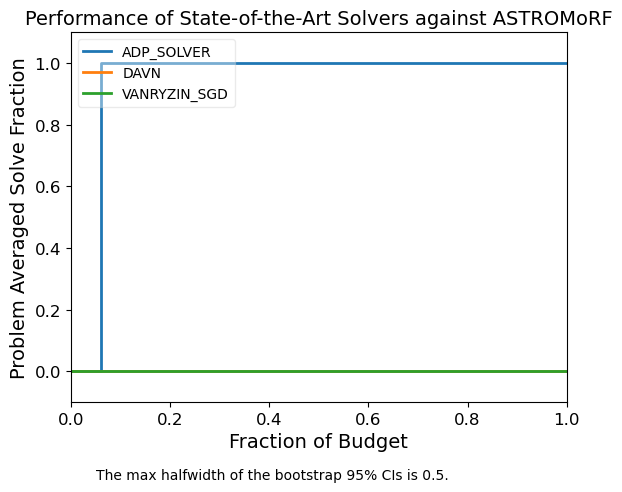

Plot saved to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/plots/Progress Curves for VANRYZIN-2 with Dimension 80.png


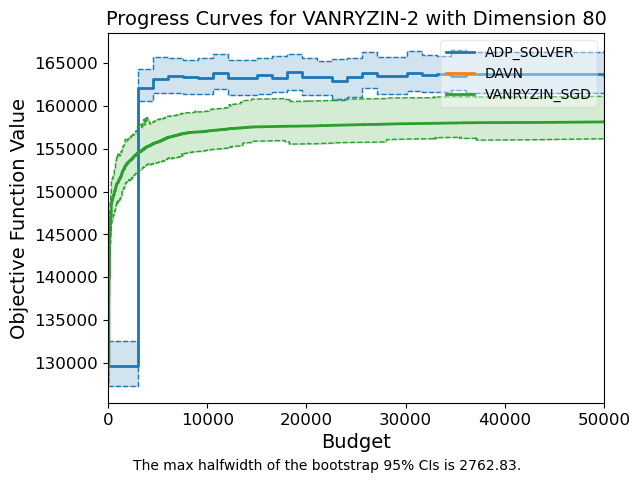

Plot saved to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/plots/Function Value Estimates for VANRYZIN-2 with Dimension 80.png


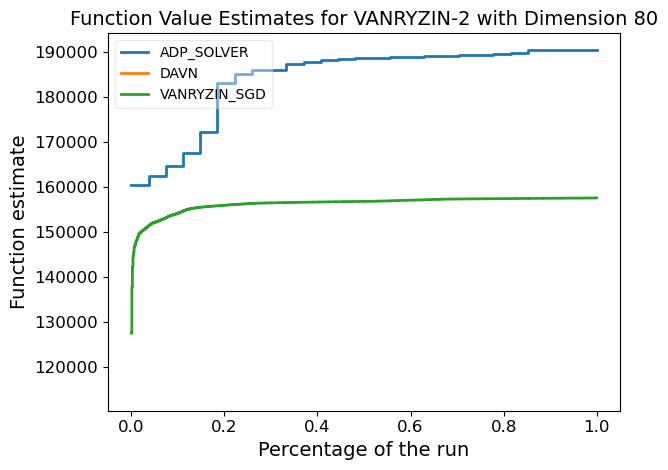

Plot saved to /Users/benjaminrees/Desktop/current_simopt_dir/notebooks/experiments/2026-04-15_20-05-01/plots/Budget History for VANRYZIN-2 with Dimension 80.png


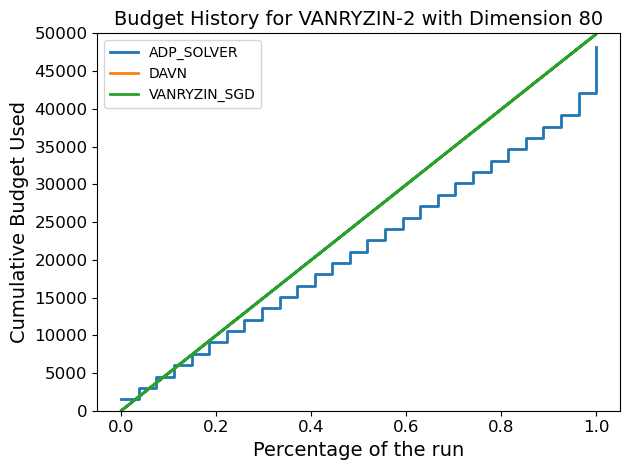

Plotting complete!


In [10]:
# Produce basic plots.
import matplotlib.pyplot as plt
from IPython.display import Image, display

from simopt.experiment_base import PlotType, plot_solvability_profiles, plot_budget_history, plot_fn_estimates, plot_progress_curves

print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of mymetaexperiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in mymetaexperiment.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []

    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_same_problem = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_same_problem.append(ps_list)



def _print_path_and_display(plot_paths: list[Path]) -> None:
    for plot_path in plot_paths:
        print(f"Plot saved to {plot_path!s}")
        display(Image(filename=str(plot_path)))


_print_path_and_display(
    plot_solvability_profiles(
        experiments=mymetaexperiment.experiments, 
        plot_type=PlotType.CDF_SOLVABILITY, 
        solve_tol=0.1, 
        plot_conf_ints=False,
        legend_loc='upper left',
        plot_title="Performance of State-of-the-Art Solvers against ASTROMoRF"

    )
)

for experiments in experiments_same_problem:
    _print_path_and_display(
        plot_progress_curves(
            experiments=experiments, 
            plot_type=PlotType.MEAN, 
            solver_set_name="Comparison of Solvers", 
            plot_title=f"Progress Curves for {experiments[0].problem.name} with Dimension {experiments[0].problem.dim}",
            normalize=False, 
            legend_loc="upper right",
            # allow_xstar_mismatch=True,
        )
    )


legend_locs = [] 
for idx in range(len(experiments_same_problem)) : 
    if experiments_same_problem[idx][0].problem.name == "PARAMESTI-1":
        legend_locs.append("upper right")
    # elif experiments_same_problem[idx][0].problem.name in ["DYNAMNEWS-1", "ROSENBROCK-1", "NETWORK-1", "SAN-1"]:
    #     legend_locs.append("lower right")
    else :
        legend_locs.append("lower right")

# for experiments, legend_loc in zip(experiments_same_problem, legend_locs):
#     if experiments[0].problem.name in ("PARAMESTI-1") :
#         _print_path_and_display(
#             plot_progress_curves(
#                 experiments=experiments, 
#                 plot_type=PlotType.MEAN, 
#                 solver_set_name="Comparison of Solvers", 
#                 plot_title=f"Progress Curves for {experiments[0].problem.name} with Dimension {experiments[0].problem.dim}",
#                 normalize=True,
#                 plot_conf_ints=False,
#                 allow_xstar_mismatch=True,
#                 legend_loc = legend_loc
#             )
#         )
#     else :
#         _print_path_and_display(
#             plot_progress_curves(
#                 experiments=experiments, 
#                 plot_type=PlotType.MEAN, 
#                 solver_set_name="Comparison of Solvers", 
#                 plot_title=f"Progress Curves for {experiments[0].problem.name} with Dimension {experiments[0].problem.dim}",
#                 normalize=False,
#                 plot_conf_ints=True,
#                 allow_xstar_mismatch=True,
#                 legend_loc = legend_loc
#             )
#         )


# for experiment in experiments_flattened:
#     _print_path_and_display(
#         plot_progress_curves(
#             experiments=[experiment], 
#             plot_type=PlotType.MEAN, 
#             solver_set_name="ASTRO-DF and ASTROMoRF", 
#             normalize=True,
#             allow_xstar_mismatch=True
#         )
#     )

# mymetaexperiment.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(mymetaexperiment.experiments)
n_problems = len(mymetaexperiment.experiments[0]) if n_solvers > 0 else 0

for prob_idx in range(n_problems):
    # Collect all solvers for this problem but remove RNDSRCH solver
    solvers_for_problem = [mymetaexperiment.experiments[solver_idx][prob_idx] for solver_idx in range(n_solvers)]

    #get the terminal budget for each problem solver 
    # [print(f"solver {s.solver.name} on problem {s.problem.name} has budget {[x[-1] for x in s.all_budget_history]}") for s in solvers_for_problem]

    _print_path_and_display(
        plot_fn_estimates(
            experiments=solvers_for_problem,
            plot_type=PlotType.FN_ESTIMATES_MEAN, 
            solver_set_name="Comparison of Solvers", 
            plot_title=f"Function Value Estimates for {solvers_for_problem[0].problem.name} with Dimension {solvers_for_problem[0].problem.dim}",
            normalize=True, 
            legend_loc="upper left",
        )
    )

    _print_path_and_display(
        plot_budget_history(
            experiments=solvers_for_problem,
            plot_type=PlotType.BUDGET_HISTORY_MEAN, 
            solver_set_name="Comparison of Solvers", 
            plot_title=f"Budget History for {solvers_for_problem[0].problem.name} with Dimension {solvers_for_problem[0].problem.dim}",
            normalize=True, 
            legend_loc="upper left",
        )
    )

print("Plotting complete!")

In [11]:
# Diagnostics: compare ADP forward estimates vs post-replicated objectives
import numpy as np

target_problem = "VANRYZIN-2"
target_solver_key = "ADP"

target_exp = None
for exp in experiments_flattened:
    if exp.problem.name == target_problem and target_solver_key in exp.solver.name:
        target_exp = exp
        break

if target_exp is None:
    print(f"No experiment found for {target_problem} with solver containing '{target_solver_key}'.")
else:
    print(f"Found {target_exp.solver.name} on {target_exp.problem.name}")
    for mrep in range(target_exp.n_macroreps):
        print("-" * 72)
        print(f"Macrorep {mrep + 1}")
        budgets = target_exp.all_intermediate_budgets[mrep]
        print("Budgets:", budgets)

        post_obj = None
        if hasattr(target_exp, "all_est_objectives") and target_exp.all_est_objectives:
            post_obj = target_exp.all_est_objectives[mrep]
            print("Post-rep objectives:", list(np.round(post_obj, 4)))
            post_best = np.maximum.accumulate(post_obj)
            print("Post-rep best-so-far:", list(np.round(post_best, 4)))
        elif target_exp.objective_curves:
            post_obj = target_exp.objective_curves[mrep].y_vals
            print("Objective curve values:", list(np.round(post_obj, 4)))
            post_best = np.maximum.accumulate(post_obj)
            print("Objective curve best-so-far:", list(np.round(post_best, 4)))
        else:
            print("Post-rep objectives not available yet (run post_replicate/post_normalize first).")

        if target_exp.all_fn_estimates is not None:
            fn_est = target_exp.all_fn_estimates[mrep]
            print("Forward GP estimates:", list(np.round(fn_est, 4)))
        else:
            print("Forward GP estimates not available (iteration_df missing).")

Found ADP_SOLVER on VANRYZIN-2
------------------------------------------------------------------------
Macrorep 1
Budgets: [0, 3021, 4530, 6027, 7536, 9045, 10548, 12051, 15060, 16566, 18075, 19572, 21081, 22593, 24096, 25593, 27102, 30117, 31626, 33120, 34623, 36132, 49997, 50000]
Post-rep objectives: [np.float64(161518.526), np.float64(162074.7611), np.float64(163161.2009), np.float64(163539.7105), np.float64(163384.9992), np.float64(163299.8606), np.float64(163817.6855), np.float64(164129.1826), np.float64(163602.4587), np.float64(163222.9531), np.float64(163954.372), np.float64(163423.5549), np.float64(163385.6972), np.float64(162881.5799), np.float64(163349.0817), np.float64(163847.803), np.float64(163528.3868), np.float64(163872.2541), np.float64(163595.5074), np.float64(163741.655), np.float64(163487.8852), np.float64(163759.6704), np.float64(163714.5444), np.float64(163597.3748)]
Post-rep best-so-far: [np.float64(161518.526), np.float64(162074.7611), np.float64(163161.2009), n

In [12]:
# Plot monotone (best-so-far) post-rep objective curves for ADP on VANRYZIN-2
import matplotlib.pyplot as plt
import numpy as np

if target_exp is None:
    print("No target experiment to plot.")
else:
    plt.figure(figsize=(7, 4))
    for mrep in range(target_exp.n_macroreps):
        budgets = target_exp.all_intermediate_budgets[mrep]
        if hasattr(target_exp, "all_est_objectives") and target_exp.all_est_objectives:
            post_obj = np.array(target_exp.all_est_objectives[mrep], dtype=float)
        elif target_exp.objective_curves:
            post_obj = np.array(target_exp.objective_curves[mrep].y_vals, dtype=float)
        else:
            print("Post-rep objectives not available; skipping plot.")
            post_obj = None
        if post_obj is None:
            continue
        post_best = np.maximum.accumulate(post_obj)
        plt.step(budgets, post_best, where="post", label=f"Macrorep {mrep + 1}")

    plt.title("ADP VANRYZIN-2 Best-So-Far Post-Rep Objectives")
    plt.xlabel("Budget")
    plt.ylabel("Objective (post-rep best-so-far)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
# Analyze budget per iteration for both solvers
print("=" * 80)
print("BUDGET ANALYSIS: ASTROMoRF vs ASTRO-DF")
print("=" * 80)

#flatten the experiments list into a single list
flatten_experiments = []
for solver_experiments in mymetaexperiment.experiments:
    for experiment in solver_experiments:
        flatten_experiments.append(experiment)

#in the flatten experiments list place common problems together
flatten_experiments.sort(key=lambda e: (e.problem.name, e.solver.name))

for experiment in flatten_experiments:
    solver_name = experiment.solver.name
    problem_name = experiment.problem.name
    problem_dim = experiment.problem.dim
    subspace_dim = None
    if solver_name.upper() == "ASTROMORF":
        subspace_dim = experiment.solver.factors.get('initial subspace dimension', 4)
    
    print(f"\n{solver_name} on {problem_name} (dim={problem_dim}):")
    print("-" * 60)
    
    for macrorep in range(experiment.n_macroreps):
        budgets = experiment.all_intermediate_budgets[macrorep]
        n_iters = len(budgets)
        
        if n_iters > 1:
            # Calculate budget spent per iteration
            budget_per_iter = [budgets[0]]  # First iteration
            for i in range(1, n_iters):
                budget_per_iter.append(budgets[i] - budgets[i-1])
            
            avg_budget_per_iter = sum(budget_per_iter) / len(budget_per_iter)
            max_budget_iter = max(budget_per_iter)
            total_budget = budgets[-1]
            
            print(f"  Macrorep {macrorep + 1}:")
            print(f"    Total iterations: {n_iters}")
            print(f"    Total budget used: {total_budget}")
            print(f"    Avg budget/iteration: {avg_budget_per_iter:.1f}")
            print(f"    Max budget in single iteration: {max_budget_iter}")
            
            # Expected design points per iteration
            if "ASTROMORF" in solver_name.upper() and subspace_dim is not None:
                # ASTROMoRF uses 2d+1 where d is subspace dimension (default 4)
                expected_points = 2 * subspace_dim + 1
                print(f"    Expected design points/iter (2*{subspace_dim}+1): {expected_points}")
            else:  # ASTRO-DF
                expected_points = 2 * problem_dim + 1
                print(f"    Expected design points/iter (2*{problem_dim}+1): {expected_points}")
            
            print(f"    Implied avg samples/point: {avg_budget_per_iter / expected_points:.1f}")

BUDGET ANALYSIS: ASTROMoRF vs ASTRO-DF

ADP_SOLVER on VANRYZIN-2 (dim=80):
------------------------------------------------------------
  Macrorep 1:
    Total iterations: 24
    Total budget used: 50000
    Avg budget/iteration: 2083.3
    Max budget in single iteration: 13865
    Expected design points/iter (2*80+1): 161
    Implied avg samples/point: 12.9

DAVN on VANRYZIN-2 (dim=80):
------------------------------------------------------------

VANRYZIN_SGD on VANRYZIN-2 (dim=80):
------------------------------------------------------------
  Macrorep 1:
    Total iterations: 834
    Total budget used: 50000
    Avg budget/iteration: 60.0
    Max budget in single iteration: 60
    Expected design points/iter (2*80+1): 161
    Implied avg samples/point: 0.4
